In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings


from sklearn.preprocessing import StandardScaler
from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
dev = qml.device("default.qubit")

In [3]:

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

# check qml.StatePre
def state_preparation(a):
    qml.RY(a[0], wires=0)

    qml.CNOT(wires=[0, 1])
    qml.RY(a[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[2], wires=1)

    qml.PauliX(wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[3], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(a[4], wires=1)
    qml.PauliX(wires=0)

@qml.qnode(dev)
def circuit(weights, x):
    state_preparation(x)
    # qml.StatePrep(x,wires=[0,1],normalize=True,pad_with=0.1)

    for layer_weights in weights:
        layer(layer_weights)

    state_preparation(x)
    # qml.StatePrep(x,wires=[0,1],normalize=True,pad_with=0.1)
    
    for layer_weights in weights:
        layer(layer_weights)

    # state_preparation(x)
    # # qml.StatePrep(x,wires=[0,1],normalize=True,pad_with=0.1)
    
    # for layer_weights in weights:
    #     layer(layer_weights)

    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(2):
        qml.Rot(*layer_weights[wire], wires=wire)
    qml.CNOT(wires=[0, 1])


def cost(weights, bias, X, Y):
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, X.T)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [4]:
def clean_data(data:pd.DataFrame,imp,enc,train=False):
    df=data

    # we get some general info about our data
    general_info(df)

    # we find the columns that have missing values and we count the total missing values
    nan_columns=df.columns[df.isna().any()].tolist()
    total_nan=(df.isna().sum()).sum()

    # we find the columns that are numeric and we drop the column id from them
    df_numeric=df.select_dtypes(include=[float, int])
    df_numeric=df_numeric.drop(columns=['id'])

    # we print some general info before the imputing
    print(f'Our data consists of {df.shape[1]} columns and {df.shape[0]} entries')
    print(f'We have {df_numeric.shape[1]} numeric columns. These are {list(df_numeric.columns)}')
    print(f'{len(nan_columns)} columns have missing values. These columns are : {nan_columns}')
    print(f'In total we have {total_nan} missing values')

    # we impute our data, thus replacing all NA values
    # df=impute(data_df=df,imp=imp,train=train)

    # we check that the imputing has indeed worked
    nan_columns=df.columns[df.isna().any()].tolist()
    print(f'We now have {len(nan_columns)} columns with missing values. These columns are : {nan_columns}')

    # we encode our two classes (Malignan -> 1, Benign -> 0)    
    df=encode(data_df=df,enc=enc,target='diagnosis',train=train)

    # we remove the duplicates
    df=remove_duplicates(df)

    # we check for outliers
    # check_for_outliers(df)

    # # but we WON'T remove them, we will just have to treat them
    # print("We WON'T remove the outliers.")

    return df


# method that returns some genral info about our dataset
def general_info(data_df: pd.DataFrame):
    print(f'Shape of dataset: {data_df.shape} ({data_df.shape[0]} entries and {data_df.shape[1]} columns)')
    print(f'Data type of the {data_df.shape[1]} columns\n {data_df.dtypes}')

# method used to impute, a.k.a replace NAs
def impute(data_df: pd.DataFrame, imp,train=False):
    df=data_df

    # we find the numeric columns of the dataframe
    df_numeric=df.select_dtypes(include=[float, int])

    # we drop id column    
    if 'id' in df_numeric.columns:
        df_numeric=df_numeric.drop(columns=['id'])

    # we use the IterativeImputer to impute
    if train == True:
    # imp=IterativeImputer(random_state=42)
        df[df_numeric.columns]=imp.fit_transform(df_numeric)
    else:
        df[df_numeric.columns]=imp.transform(df_numeric)

    return df

def encode(data_df: pd.DataFrame,enc,target='diagnosis',train=False):
    """
    Method used to encode the entries of the column 'diagnosis'
    Malignant --> 1
    Benign --> -1
    """
    df=data_df
    
    # we use the LabelEncoder to encode the two classes
    if train == True:
        df[target]=enc.fit_transform(df[target]) # M->1, B->-1
    else:
        df[target]=enc.transform(df[target]) # M->1, B->-1        
    # df[target]=df[target].astype(int)
    df[target]=2 * df[target] - 1

    return df
    

def remove_duplicates(data_df: pd.DataFrame):
    """
    We use this function to find and remove any potential duplicates
    """
    
    df=data_df
   
    shape_before=df.shape
    df.drop_duplicates()
    shape_after=df.shape

    # we check for diffences in the shape. If there are, then the dataset used to have duplicate values
    if (shape_before[0] != shape_after[0]):
        print("Before removal of duplicates",shape_before)
        print("After removal of duplicates",shape_after)
    else:
        print("No duplicates in the set")
    
    return df

# method used to check for outliers and predict what our data would look like without them
def check_for_outliers(data_df: pd.DataFrame):

    df=data_df
   
    shape_before=df.shape
    
    # we drop all the outliers
    no_outliers=df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]

    shape_after=no_outliers.shape

    # If there are differences in shape, then our dataset had outliers. We suggest what would happen if we were to remove them
    if (shape_before[0] != shape_after[0]):
        removed=shape_before[0]-shape_after[0]
        print("Before removal of outliers",shape_before)
        class_imbalance(df)
        print("After removal of outliers",shape_after)
        class_imbalance(no_outliers)
        print(f"We could remove {removed} entries ({(removed/shape_before[0])*100:.2f}% of total entries)")

    else:
        print("No outliers in the set")

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [5]:
# 1. Read the original CSV
df = pd.read_csv('./cancer_data/data.csv')

# 2. Drop the empty column if it exists
if 'Unnamed: 32' in df.columns:
    print('Added Unnamed!')
    df = df.drop(columns=['Unnamed: 32'])

# 3. Save the dataframe back to a CSV
# index=False prevents pandas from adding row numbers as a new column
df.to_csv('./cancer_data/data_cleaned.csv', index=False)

class_imbalance(data_df=df)


# X = all columns except diagnosis
# y = diagnosis column
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,       # 40% goes to the second subset
    stratify=y,          # this ensures class imbalance is preserved
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,           # half of 40% = 20% of total
    stratify=y_temp,
    random_state=42
)

# If you want them back as DataFrames with the diagnosis column included:
train_df = X_train.copy()
train_df["diagnosis"] = y_train
train_df.to_csv('./cancer_data/train_subset.csv', index=False)

val_df = X_val.copy()
val_df["diagnosis"] = y_val
val_df.to_csv('./cancer_data/val_subset.csv',index=False)

test_df = X_test.copy()
test_df["diagnosis"] = y_test
test_df.to_csv('./cancer_data/test_subset.csv', index=False)



Added Unnamed!
Absolute frequencies of field "diagnosis"
diagnosis
B    357
M    212
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [6]:
df_train=pd.read_csv('./cancer_data/train_subset.csv')

df_train.head()

class_imbalance(data_df=df_train)

Absolute frequencies of field "diagnosis"
diagnosis
B    214
M    127
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
B    0.627566
M    0.372434
Name: proportion, dtype: float64


In [7]:
imp=IterativeImputer(random_state=42)
enc=LabelEncoder()

In [8]:
df_train_clean=clean_data(df_train,imp=imp,enc=enc,train=True)
y_train=df_train_clean['diagnosis'].values

Shape of dataset: (341, 32) (341 entries and 32 columns)
Data type of the 32 columns
 id                           int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
comp

In [9]:
df_train_clean.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,859283,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,...,33.39,114.60,925.1,0.16480,0.34160,0.3024,0.16140,0.3321,0.08911,1
1,9113778,9.667,18.49,61.49,289.1,0.08946,0.06258,0.02948,0.01514,0.2238,...,25.62,70.88,385.2,0.12340,0.15420,0.1277,0.06560,0.3174,0.08524,-1
2,913102,14.640,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.02791,0.1409,...,25.44,106.00,831.0,0.11420,0.20700,0.2437,0.07828,0.2455,0.06596,-1
3,90312,19.550,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,...,30.44,142.00,1313.0,0.12510,0.24140,0.3829,0.18250,0.2576,0.07602,1
4,9113846,12.270,29.97,77.42,465.4,0.07699,0.03398,0.00000,0.00000,0.1701,...,38.05,85.08,558.9,0.09422,0.05213,0.0000,0.00000,0.2409,0.06743,-1


In [10]:
df_train_clean.to_csv('./cancer_data/clean_train_subset.csv', index=False)
class_imbalance(data_df=df_train_clean)

Absolute frequencies of field "diagnosis"
diagnosis
-1    214
 1    127
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627566
 1    0.372434
Name: proportion, dtype: float64


In [11]:
y_clean_train=df_train_clean['diagnosis']
id=df_train_clean['id']
x_clean_train=df_train_clean.drop(columns=['diagnosis','id'])
x_clean_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,0.06654,...,17.31,33.39,114.60,925.1,0.16480,0.34160,0.3024,0.16140,0.3321,0.08911
1,9.667,18.49,61.49,289.1,0.08946,0.06258,0.02948,0.01514,0.2238,0.06413,...,11.14,25.62,70.88,385.2,0.12340,0.15420,0.1277,0.06560,0.3174,0.08524
2,14.640,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.02791,0.1409,0.05355,...,16.46,25.44,106.00,831.0,0.11420,0.20700,0.2437,0.07828,0.2455,0.06596
3,19.550,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,0.05884,...,20.82,30.44,142.00,1313.0,0.12510,0.24140,0.3829,0.18250,0.2576,0.07602
4,12.270,29.97,77.42,465.4,0.07699,0.03398,0.00000,0.00000,0.1701,0.05960,...,13.45,38.05,85.08,558.9,0.09422,0.05213,0.0000,0.00000,0.2409,0.06743


In [12]:
scaler=StandardScaler()
x_scaled_train=scaler.fit_transform(x_clean_train)

In [13]:
pca=PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled_train)

print(pca.explained_variance_ratio_)

[0.42963015 0.19950608]


In [14]:

# Put back into a DataFrame if you want
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = y_clean_train.reset_index(drop=True)
df_pca['id']=id.reset_index(drop=True)

df_pca.head()

,PC1,PC2,diagnosis,id
0,1.894844,0.718495,1,859283
1,-2.624631,1.612483,-1,9113778
2,-2.272971,-2.213912,-1,913102
3,4.788503,-0.538268,1,90312
4,-3.514492,-1.374225,-1,9113846


In [15]:
df_pca.to_csv('./pca_datasets/pca2_clean_train_subset.csv',index=False)

In [16]:
y_pca_train=df_pca['diagnosis']
x_pca_train=df_pca.drop(columns=['diagnosis','id'])
x_pca_train=x_pca_train.to_numpy()
x_pca_train

array([[ 1.89484382e+00,  7.18494621e-01],
       [-2.62463063e+00,  1.61248293e+00],
       [-2.27297056e+00, -2.21391159e+00],
       [ 4.78850326e+00, -5.38268424e-01],
       [-3.51449164e+00, -1.37422486e+00],
       [-3.44111834e+00, -4.63721141e-01],
       [-3.53629728e-01, -3.61754328e-01],
       [-3.54079298e+00,  1.08549293e+00],
       [-4.60970676e+00, -1.55787590e+00],
       [-8.28513990e-01, -3.44758290e+00],
       [ 1.24897245e+01, -8.36722529e+00],
       [ 6.42961614e+00, -2.04330241e+00],
       [-9.08542548e-01, -2.15463799e+00],
       [ 2.32536545e+00, -3.42245376e-01],
       [ 2.18461546e+00,  1.69503152e-01],
       [ 2.27884731e+00, -2.61858730e+00],
       [-1.33641970e+00,  3.55508627e-01],
       [ 1.79037402e+00,  2.48557049e+00],
       [ 2.58527802e+00,  4.78387815e+00],
       [ 2.84669255e+00, -1.05588114e+00],
       [-3.27759667e+00,  8.02689364e-01],
       [ 3.40011828e+00, -3.41326183e+00],
       [ 5.02252866e+00, -1.14230545e+00],
       [-1.

In [17]:
print(f"First X sample (original)  : {x_pca_train[0]}")

padding = np.ones((len(x_pca_train), 2)) * 0.1
x_train_pad=np.c_[x_pca_train,padding]
print(f"First X sample (padded)    : {x_train_pad[0]}")

normalization=1
normalization = np.sqrt(np.sum(x_train_pad**2, -1))
x_train_norm = (x_train_pad.T / normalization).T

minmaxscaler=MinMaxScaler()

x_train_norm = minmaxscaler.fit_transform(x_train_norm)
print(f"First X sample (normalized): {x_train_norm[0]}")

First X sample (original)  : [1.89484382 0.71849462]
First X sample (padded)    : [1.89484382 0.71849462 0.1        0.1       ]
First X sample (normalized): [0.96671478 0.67592158 0.06527365 0.06527365]


In [18]:
features = np.array([get_angles(x) for x in x_train_norm],requires_grad=False)
# features = np.array([x for x in x_pca_train],requires_grad=False)
print(f"First features sample      : {features[0]}")
# features=x_train_norm
# features=x_pca_train

First features sample      : [ 0.15619658 -0.78539816  0.78539816 -0.6101851   0.6101851 ]


In [19]:
# plt.figure()
# plt.scatter(x_pca_train[:, 0][y_pca_train == 1], x_pca_train[:, 1][y_pca_train == 1], c="b", marker="o", ec="k")
# plt.scatter(x_pca_train[:, 0][y_pca_train == -1], x_pca_train[:, 1][y_pca_train == -1], c="r", marker="o", ec="k")
# plt.title("Original data")
# plt.show()


# plt.figure(figsize=(8, 6))
# color_map = {1: 'blue', -1: 'red'}
# for label in df_pca['diagnosis'].unique():
#     subset = df_pca[df_pca['diagnosis'] == label]
#     plt.scatter(subset['PC1'], subset['PC2'],color=color_map[label], label=f'Class {label}', alpha=0.7)

# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Original Datapoints (Train Data)')
# plt.legend()
# plt.grid(True)
# plt.show()

# for dim1 in range(4):
#     for dim2 in range(dim1+1,4):
#         plt.figure()
#         # dim1 = 0
#         # dim2 = 1
#         plt.scatter(x_train_norm[:, dim1][y_pca_train == 1], x_train_norm[:, dim2][y_pca_train == 1], c="b", marker="o", ec="k")
#         plt.scatter(x_train_norm[:, dim1][y_pca_train == -1], x_train_norm[:, dim2][y_pca_train == -1], c="r", marker="o", ec="k")
#         plt.title(f"Padded and normalised data (dims {dim1} and {dim2}) (Train Data)")
#         plt.show()

#         plt.figure()
#         # dim1 = 0
#         # dim2 = 3
#         plt.scatter(features[:, dim1][y_pca_train == 1], features[:, dim2][y_pca_train == 1], c="b", marker="o", ec="k")
#         plt.scatter(features[:, dim1][y_pca_train == -1], features[:, dim2][y_pca_train == -1], c="r", marker="o", ec="k")
#         plt.title(f"Feature vectors (dims {dim1} and {dim2}) (Train Data)")
#         plt.show()


In [20]:
df_val=pd.read_csv('./cancer_data/val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

Absolute frequencies of field "diagnosis"
diagnosis
B    71
M    43
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
B    0.622807
M    0.377193
Name: proportion, dtype: float64


In [21]:
df_val_clean=clean_data(df_val,imp=imp,enc=enc,train=False)
y_val=df_val_clean['diagnosis'].values

Shape of dataset: (114, 32) (114 entries and 32 columns)
Data type of the 32 columns
 id                           int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
comp

In [22]:
df_val_clean.to_csv('./cancer_data/clean_val_subset.csv', index=False)
class_imbalance(data_df=df_val_clean)

Absolute frequencies of field "diagnosis"
diagnosis
-1    71
 1    43
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.622807
 1    0.377193
Name: proportion, dtype: float64


In [23]:
y_clean_val=df_val_clean['diagnosis']
id_val=df_val_clean['id']
x_clean_val=df_val_clean.drop(columns=['diagnosis','id'])
x_clean_val.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.160,18.03,78.29,455.3,0.09087,0.07838,0.02916,0.015270,0.1464,0.06284,...,13.34,27.87,88.83,547.4,0.1208,0.22790,0.16200,0.05690,0.2406,0.07729
1,12.720,13.78,81.78,492.1,0.09667,0.08393,0.01288,0.019240,0.1638,0.06100,...,13.50,17.48,88.54,553.7,0.1298,0.14720,0.05233,0.06343,0.2369,0.06922
2,9.683,19.34,61.05,285.7,0.08491,0.05030,0.02337,0.009615,0.1580,0.06235,...,10.93,25.59,69.10,364.2,0.1199,0.09546,0.09350,0.03846,0.2552,0.07920
3,11.670,20.02,75.21,416.2,0.10160,0.09453,0.04200,0.021570,0.1859,0.06461,...,13.35,28.81,87.00,550.6,0.1550,0.29640,0.27580,0.08120,0.3206,0.08950
4,12.700,12.17,80.88,495.0,0.08785,0.05794,0.02360,0.024020,0.1583,0.06275,...,13.65,16.92,88.12,566.9,0.1314,0.16070,0.09385,0.08224,0.2775,0.09464


In [24]:
scaler_val=StandardScaler()
# x_scaled_val=scaler_val.fit_transform(x_clean_val)
x_scaled_val=scaler.transform(x_clean_val)

In [25]:
pca_val=PCA(n_components=2)
# X_pca_val = pca_val.fit_transform(x_scaled_val)
X_pca_val = pca.transform(x_scaled_val)

print(pca.explained_variance_ratio_)

[0.42963015 0.19950608]


In [26]:
# Put back into a DataFrame if you want
df_pca_val = pd.DataFrame(X_pca_val, columns=['PC1', 'PC2'])
df_pca_val['diagnosis'] = y_clean_val.reset_index(drop=True)
df_pca_val['id']=id_val.reset_index(drop=True)

df_pca_val.head(20)

,PC1,PC2,diagnosis,id
0,-2.958676,-0.458180,-1,912193
1,-3.287326,-0.538549,-1,891716
2,-3.789048,0.662042,-1,923169
3,-1.728430,1.018779,-1,91903901
4,-2.843913,0.243963,-1,906024
5,-2.344605,-0.093068,-1,9010598
6,-3.715613,0.909143,-1,874158
7,-4.382366,3.656472,-1,862722
8,-0.889550,1.017601,-1,861597
9,1.686734,6.406699,-1,894329


In [27]:
df_pca_val.to_csv('./pca_datasets/pca2_clean_val_subset.csv',index=False)

In [28]:
y_pca_val=df_pca_val['diagnosis']
x_pca_val=df_pca_val.drop(columns=['diagnosis','id'])
x_pca_val=x_pca_val.to_numpy()
x_pca_val

array([[-2.95867649e+00, -4.58180143e-01],
       [-3.28732564e+00, -5.38549124e-01],
       [-3.78904761e+00,  6.62042022e-01],
       [-1.72843026e+00,  1.01877855e+00],
       [-2.84391287e+00,  2.43962862e-01],
       [-2.34460512e+00, -9.30683720e-02],
       [-3.71561286e+00,  9.09143308e-01],
       [-4.38236562e+00,  3.65647162e+00],
       [-8.89550105e-01,  1.01760083e+00],
       [ 1.68673394e+00,  6.40669925e+00],
       [-2.80062929e+00, -7.19054676e-01],
       [-3.77097853e-01,  2.93029479e-01],
       [-2.34405719e+00,  8.15828606e-01],
       [-2.52481231e+00,  3.25841141e-01],
       [-2.42267554e+00,  3.08156070e+00],
       [ 2.67655699e+00, -4.02893596e+00],
       [-2.67170501e+00, -7.53132330e-03],
       [ 1.10963284e+01, -4.01251159e+00],
       [-1.25633574e+00,  1.57349592e+00],
       [ 1.76398982e+00,  1.57284053e+00],
       [ 1.05396964e+00,  2.62559456e+00],
       [-2.22120110e+00,  9.42163971e-02],
       [ 1.63808206e+01, -8.52543061e+00],
       [ 7.

In [29]:
print(f"First X VAL sample (original)  : {x_pca_val[0]}")

padding_val = np.ones((len(x_pca_val), 2)) * 0.1
x_val_pad=np.c_[x_pca_val,padding_val]
print(f"First X VAL sample (padded)    : {x_val_pad[0]}")

normalization_val=1
normalization_val = np.sqrt(np.sum(x_val_pad**2, -1))
x_val_norm = (x_val_pad.T / normalization_val).T
x_val_norm = minmaxscaler.transform(x_val_norm)
print(f"First X VAL sample (normalized): {x_val_norm[0]}")

First X VAL sample (original)  : [-2.95867649 -0.45818014]
First X VAL sample (padded)    : [-2.95867649 -0.45818014  0.1         0.1       ]
First X VAL sample (normalized): [0.00608825 0.42171357 0.0409533  0.0409533 ]


In [30]:
features_val = np.array([get_angles(x) for x in x_val_norm],requires_grad=False)
# features_val = np.array([x for x in x_pca_val],requires_grad=False)
print(f"First VAL features sample      : {features_val[0]}")
# features_val=x_val_norm
# features_val=x_pca_val

First VAL features sample      : [ 0.27293754 -0.78539816  0.78539816 -1.55636039  1.55636039]


In [31]:
# plt.figure()
# plt.scatter(x_pca_val[:, 0][y_pca_val == 1], x_pca_val[:, 1][y_pca_val == 1], c="b", marker="o", ec="k")
# plt.scatter(x_pca_val[:, 0][y_pca_val == -1], x_pca_val[:, 1][y_pca_val == -1], c="r", marker="o", ec="k")
# plt.title("Original data VAL")
# plt.show()


# plt.figure(figsize=(8, 6))
# color_map = {1: 'blue', -1: 'red'}
# for label in df_pca_val['diagnosis'].unique():
#     subset = df_pca_val[df_pca_val['diagnosis'] == label]
#     plt.scatter(subset['PC1'], subset['PC2'],color=color_map[label], label=f'Class {label}', alpha=0.7)

# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Original Datapoints (VAL Data)')
# plt.legend()
# plt.grid(True)
# plt.show()

# for dim1 in range(4):
#     for dim2 in range(dim1+1,4):
#         plt.figure()
#         # dim1 = 0
#         # dim2 = 1
#         plt.scatter(x_val_norm[:, dim1][y_pca_val == 1], x_val_norm[:, dim2][y_pca_val == 1], c="b", marker="o", ec="k")
#         plt.scatter(x_val_norm[:, dim1][y_pca_val == -1], x_val_norm[:, dim2][y_pca_val == -1], c="r", marker="o", ec="k")
#         plt.title(f"Padded and normalised data (dims {dim1} and {dim2}) (VAL Data)")
#         plt.show()

#         plt.figure()
#         # dim1 = 0
#         # dim2 = 3
#         plt.scatter(features_val[:, dim1][y_pca_val == 1], features_val[:, dim2][y_pca_val == 1], c="b", marker="o", ec="k")
#         plt.scatter(features_val[:, dim1][y_pca_val == -1], features_val[:, dim2][y_pca_val == -1], c="r", marker="o", ec="k")
#         plt.title(f"Feature vectors (dims {dim1} and {dim2}) (VAL Data)")
#         plt.show()

In [32]:
df_test=pd.read_csv('./cancer_data/test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
B    72
M    42
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
B    0.631579
M    0.368421
Name: proportion, dtype: float64


In [33]:
df_test_clean=clean_data(df_test,imp=imp,enc=enc,train=False)
y_test=df_test_clean['diagnosis'].values

Shape of dataset: (114, 32) (114 entries and 32 columns)
Data type of the 32 columns
 id                           int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
comp

In [34]:
df_test_clean.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,8612080,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,...,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924,-1
1,865432,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,...,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006,-1
2,863270,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,...,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185,-1
3,873843,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,...,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427,-1
4,8510653,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,...,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183,-1


In [35]:
df_test_clean.to_csv('./cancer_data/clean_test_subset.csv', index=False)
class_imbalance(data_df=df_test_clean)

Absolute frequencies of field "diagnosis"
diagnosis
-1    72
 1    42
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631579
 1    0.368421
Name: proportion, dtype: float64


In [36]:
y_clean_test=df_test_clean['diagnosis']
id_test=df_test_clean['id']
x_clean_test=df_test_clean.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
1,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006
2,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.06066,...,13.29,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185
3,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
4,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


In [37]:
# scaler_test=RobustScaler()
# x_scaled_test=scaler_test.fit_transform(x_clean_test)
x_scaled_test=scaler.transform(x_clean_test)

In [38]:
# pca_test=PCA(n_components=2)
# X_pca_test = pca_test.fit_transform(x_scaled_test)
X_pca_test = pca.transform(x_scaled_test)

print(pca.explained_variance_ratio_)

[0.42963015 0.19950608]


In [39]:
# Put back into a DataFrame if you want
df_pca_test = pd.DataFrame(X_pca_test, columns=['PC1', 'PC2'])
df_pca_test['diagnosis'] = y_clean_test.reset_index(drop=True)
df_pca_test['id']=id_test.reset_index(drop=True)

df_pca_test.head(20)

,PC1,PC2,diagnosis,id
0,-2.098770,0.694780,-1,8612080
1,-0.683297,0.136716,-1,865432
2,-3.150343,-0.737499,-1,863270
3,-2.605396,0.679590,-1,873843
4,-1.503633,0.789427,-1,8510653
5,-2.909342,-0.291566,-1,905502
6,-3.284657,0.105472,-1,893783
7,0.801995,3.365031,-1,911366
8,1.294880,6.730723,-1,872608
9,4.113791,2.991844,1,84799002


In [40]:
df_pca_test.to_csv('./pca_datasets/pca2_clean_test_subset.csv',index=False)

In [41]:
y_pca_test=df_pca_test['diagnosis']
x_pca_test=df_pca_test.drop(columns=['diagnosis','id'])
x_pca_test=x_pca_test.to_numpy()
x_pca_test

array([[-2.09877034e+00,  6.94779904e-01],
       [-6.83296870e-01,  1.36716255e-01],
       [-3.15034333e+00, -7.37498764e-01],
       [-2.60539599e+00,  6.79589847e-01],
       [-1.50363305e+00,  7.89426969e-01],
       [-2.90934160e+00, -2.91565723e-01],
       [-3.28465735e+00,  1.05472237e-01],
       [ 8.01995160e-01,  3.36503142e+00],
       [ 1.29487951e+00,  6.73072295e+00],
       [ 4.11379127e+00,  2.99184446e+00],
       [-6.58418544e-01,  1.75385710e+00],
       [ 9.59902945e+00, -5.92382424e+00],
       [-2.36752135e+00, -3.93146982e-03],
       [-5.60803905e-01, -6.71056018e-01],
       [-1.15754801e+00,  3.48668182e+00],
       [-1.91171099e+00,  5.36320216e-01],
       [-3.89508819e-01, -7.70451449e-01],
       [ 5.02844288e+00, -1.63138444e+00],
       [ 3.30162714e+00, -4.01608650e+00],
       [-9.16536875e-01, -1.55597767e+00],
       [-2.52149861e+00, -4.86138936e-01],
       [ 7.95422263e-02, -3.39271675e+00],
       [-2.79855477e+00, -2.82572839e-01],
       [ 4.

In [42]:
print(f"First X TEST sample (original)  : {x_pca_test[0]}")

padding_test = np.ones((len(x_pca_test), 2)) * 0.1
x_test_pad=np.c_[x_pca_test,padding_test]
print(f"First X TEST sample (padded)    : {x_test_pad[0]}")

normalization_test=1
normalization_test = np.sqrt(np.sum(x_test_pad**2, -1))
x_test_norm = (x_test_pad.T / normalization_test).T
x_test_norm = minmaxscaler.transform(x_test_norm)
print(f"First X TEST sample (normalized): {x_test_norm[0]}")

First X TEST sample (original)  : [-2.09877034  0.6947799 ]
First X TEST sample (padded)    : [-2.09877034  0.6947799   0.1         0.1       ]
First X TEST sample (normalized): [0.02596359 0.65581654 0.05900917 0.05900917]


In [43]:
features_test = np.array([get_angles(x) for x in x_test_norm],requires_grad=False)
# features_test = np.array([x for x in x_pca_test],requires_grad=False)
print(f"First features sample TEST      : {features_test[0]}")
# features_test=x_test_norm
# features_test=x_pca_test

First features sample TEST      : [ 0.25294023 -0.78539816  0.78539816 -1.53122728  1.53122728]


In [44]:
# plt.figure(figsize=(8, 6))
# color_map = {1: 'blue', -1: 'red'}
# for label in df_pca_test['diagnosis'].unique():
#     subset = df_pca_test[df_pca_test['diagnosis'] == label]
#     plt.scatter(subset['PC1'], subset['PC2'],color=color_map[label], label=f'Class {label}', alpha=0.7)

# plt.xlabel('x')
# plt.ylabel('y')
# plt.title('Original Datapoints (TEST Data)')
# plt.legend()
# plt.grid(True)
# plt.show()

# for dim1 in range(4):
#     for dim2 in range(dim1+1,4):
#         plt.figure()
#         # dim1 = 0
#         # dim2 = 1
#         plt.scatter(x_test_norm[:, dim1][y_pca_test == 1], x_test_norm[:, dim2][y_pca_test == 1], c="b", marker="o", ec="k")
#         plt.scatter(x_test_norm[:, dim1][y_pca_test == -1], x_test_norm[:, dim2][y_pca_test == -1], c="r", marker="o", ec="k")
#         plt.title(f"Padded and normalised data (dims {dim1} and {dim2}) (TEST Data)")
#         plt.show()

#         plt.figure()
#         # dim1 = 0
#         # dim2 = 3
#         plt.scatter(features_test[:, dim1][y_pca_test == 1], features_test[:, dim2][y_pca_test == 1], c="b", marker="o", ec="k")
#         plt.scatter(features_test[:, dim1][y_pca_test == -1], features_test[:, dim2][y_pca_test == -1], c="r", marker="o", ec="k")
#         plt.title(f"Feature vectors (dims {dim1} and {dim2}) (TEST Data)")
#         plt.show()

In [45]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

In [46]:
num_qubits = 2
num_layers = 2

weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
bias_init = np.array(0.0,requires_grad=True)

Iter:   2 | Cost: 2.0625102 | Acc Train: 0.4018 | Acc Val: 0.3947 | Precision: 0.5659 | Recall: 0.5095 | F1: 0.3145
Iter:   4 | Cost: 1.9668659 | Acc Train: 0.4106 | Acc Val: 0.3947 | Precision: 0.5659 | Recall: 0.5095 | F1: 0.3145
Iter:   6 | Cost: 1.6954124 | Acc Train: 0.4164 | Acc Val: 0.3860 | Precision: 0.4881 | Recall: 0.4979 | F1: 0.3092
Iter:   8 | Cost: 1.2088231 | Acc Train: 0.4575 | Acc Val: 0.4123 | Precision: 0.5684 | Recall: 0.5190 | F1: 0.3511
Iter:  10 | Cost: 0.7706149 | Acc Train: 0.6158 | Acc Val: 0.5877 | Precision: 0.6640 | Recall: 0.6461 | F1: 0.5851
Iter:  12 | Cost: 0.5495700 | Acc Train: 0.8915 | Acc Val: 0.9211 | Precision: 0.9220 | Recall: 0.9091 | F1: 0.9147
Iter:  14 | Cost: 0.4961775 | Acc Train: 0.8651 | Acc Val: 0.8684 | Precision: 0.8895 | Recall: 0.8348 | F1: 0.8510
Iter:  16 | Cost: 0.5084695 | Acc Train: 0.8270 | Acc Val: 0.8509 | Precision: 0.8891 | Recall: 0.8069 | F1: 0.8261
Iter:  18 | Cost: 0.4645535 | Acc Train: 0.8387 | Acc Val: 0.8509 | Prec

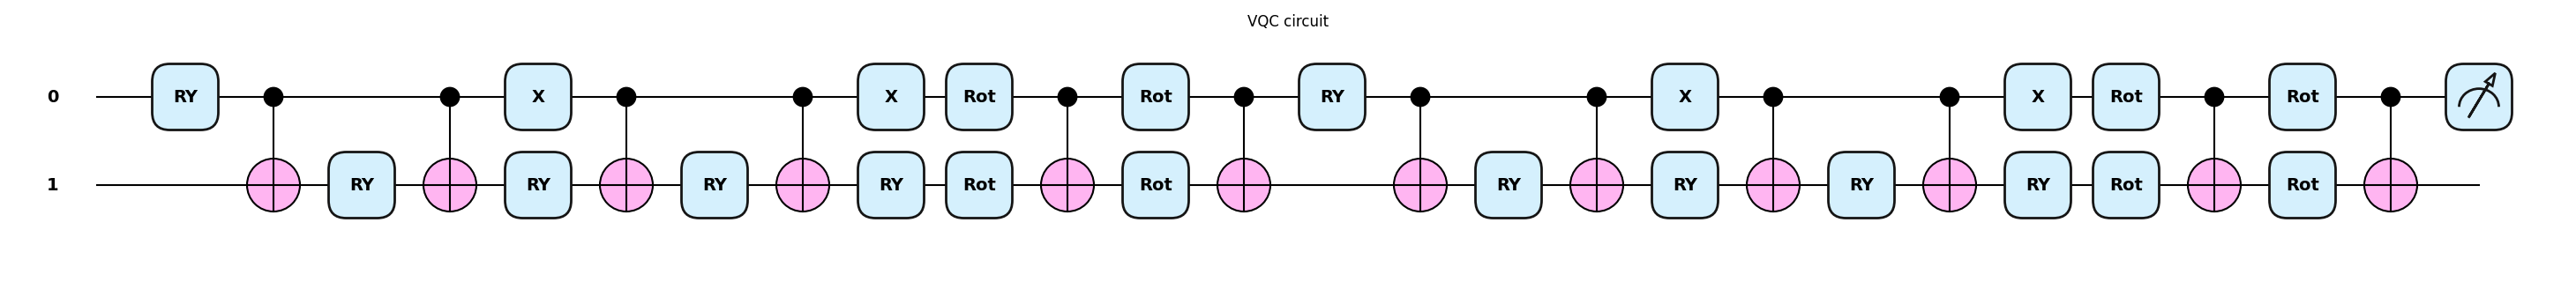

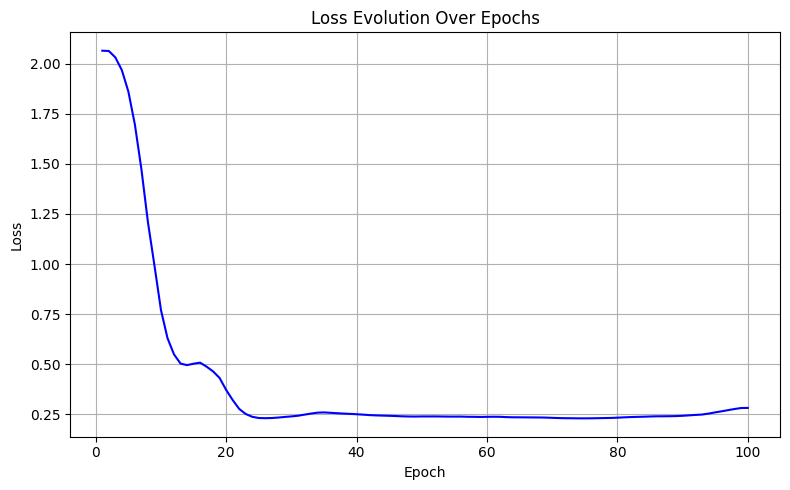

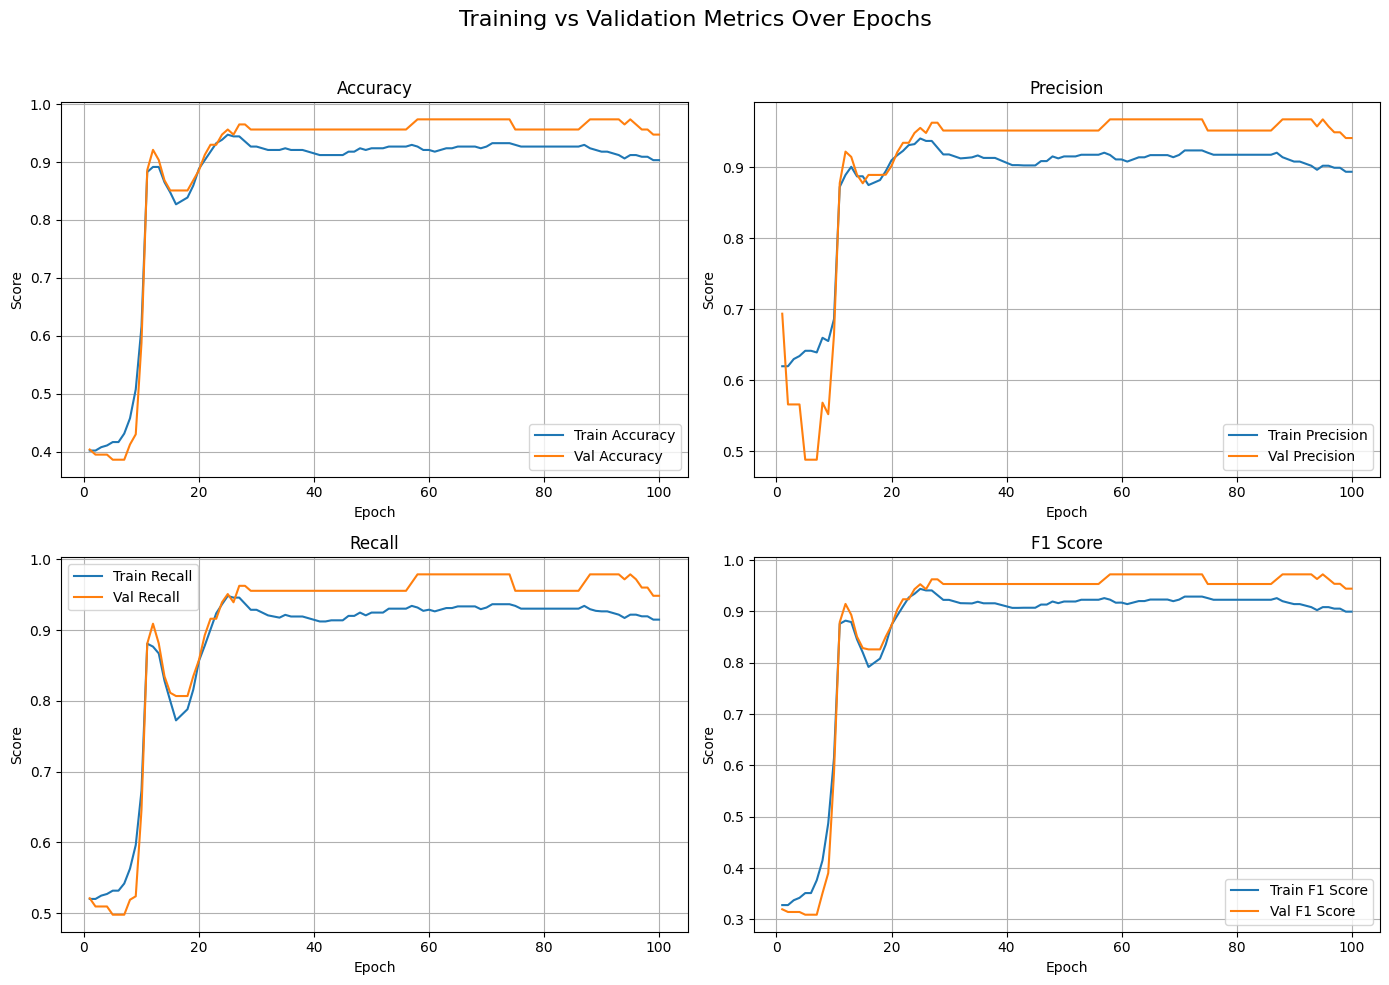

In [47]:

opt = NesterovMomentumOptimizer(0.01)
batch_size = 5
# batch_size = 4
num_epochs = 100

# Tracking loss
losses = []

# Tracking Train accuracy
tr_acc=[]

# Tracking Validation accuracy
val_acc=[]

# Tracking Train precision
tr_prec=[]

# Tracking Validation precision
val_prec=[]

# Tracking Train recall
tr_recall=[]

# Tracking Validation recall
val_recall=[]

# Tracking Train F1
tr_f1=[]

# Tracking Validation F1
val_f1=[]

# Initialize weights
weights = weights_init
bias = bias_init

for it in range(num_epochs):
    # Mini-batch sampling
    # batch_index = np.random.randint(0, num_train, (batch_size,))
    batch_index = np.random.randint(0, num_data, (batch_size,))
    feats_train_batch = features[batch_index]
    Y_train_batch = y_train[batch_index]

    # Optimizer step
    weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

    plot=False
    # Predictions
    if it==99:
        plot=True

    pred_train = np.sign(variational_classifier(weights, bias, features.T,plot=plot))
    pred_val = np.sign(variational_classifier(weights, bias, features_val.T))

    # Metrics
    acc_train = accuracy_score(y_train, pred_train)
    acc_val = accuracy_score(y_val, pred_val)
    prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
    prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
    rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
    rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
    f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
    f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

    tr_acc.append(acc_train)
    val_acc.append(acc_val)
    tr_prec.append(prec_train)
    val_prec.append(prec_val)
    tr_recall.append(rec_train)
    val_recall.append(rec_val)
    tr_f1.append(f1_train)
    val_f1.append(f1_val)

    # Track loss
    _cost = cost(weights, bias, features, y_train)
    losses.append(_cost)

    if (it + 1) % 2 == 0:
        print(
            f"Iter: {it + 1:3d} | Cost: {_cost:0.7f} | "
            f"Acc Train: {acc_train:0.4f} | Acc Val: {acc_val:0.4f} | "
            f"Precision: {prec_val:0.4f} | Recall: {rec_val:0.4f} | F1: {f1_val:0.4f}"
        )
    weights=weights_new
    bias-bias_new

# After training: evaluate on test set
pred_test = np.sign(variational_classifier(weights, bias, features_test.T))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

print("\n Final Test Set Evaluation:")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), losses, linestyle='-', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Evolution Over Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, tr_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, tr_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, tr_recall, label='Train Recall', linestyle='-')
plt.plot(epochs_range, val_recall, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, tr_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle('Training vs Validation Metrics Over Epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [48]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-Score : {metrics_dict['f1']:.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [49]:
# Classical ML method: SVM
svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=svm_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=svm_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=svm_clf)

print("-----> SVM Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> SVM Results <-----

Train Set:
  Accuracy : 0.9532
  Precision: 0.9467
  Recall   : 0.9302
  F1-Score : 0.9359

Validation Set:
  Accuracy : 0.9387
  Precision: 0.9111
  Recall   : 0.9333
  F1-Score : 0.9216

Test Set:
  Accuracy : 0.9387
  Precision: 0.9556
  Recall   : 0.8806
  F1-Score : 0.9123


In [50]:
# Classical ML method: Logistic Regression
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=lr_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=lr_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=lr_clf)

print("-----> Logistic Regression Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Logistic Regression Results <-----

Train Set:
  Accuracy : 0.9561
  Precision: 0.9467
  Recall   : 0.9378
  F1-Score : 0.9405

Validation Set:
  Accuracy : 0.9561
  Precision: 0.9528
  Recall   : 0.9333
  F1-Score : 0.9412

Test Set:
  Accuracy : 0.9296
  Precision: 0.9556
  Recall   : 0.8556
  F1-Score : 0.8971


In [51]:
# Classical ML method: Random Forest
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=forest_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=forest_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=forest_clf)

print("-----> Random Forest Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Random Forest Results <-----

Train Set:
  Accuracy : 0.9297
  Precision: 0.9205
  Recall   : 0.8908
  F1-Score : 0.9031

Validation Set:
  Accuracy : 0.9300
  Precision: 0.9111
  Recall   : 0.9111
  F1-Score : 0.9070

Test Set:
  Accuracy : 0.9209
  Precision: 0.9306
  Recall   : 0.8583
  F1-Score : 0.8874
